# Stock Price Forecasting with LSTM

This notebook builds an end-to-end stock forecasting workflow using **yfinance**, technical indicators, preprocessing, an LSTM model, evaluation, and 15-step forecasting. The notebook prompts the user for ticker, date range, and interval at runtime, which matches a reusable yfinance download workflow using `start`, `end`, and `interval` parameters.

The preprocessing and modeling flow follows standard TensorFlow time-series guidance: preserve chronological order, normalize numeric features, and convert the data into sliding windows for recurrent forecasting models.

## 1. Install and import libraries

Run the next cell once if your environment does not already have the required packages.

In [1]:

%pip install yfinance pandas numpy matplotlib scikit-learn tensorflow seaborn


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import math
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('deep')

## 2. Prompt the user for inputs

This notebook asks the user to enter the stock ticker, start date, end date, and interval directly in code so the workflow can be reused for different securities and timeframes.

In [3]:
VALID_INTERVALS = {
    '1m', '2m', '5m', '15m', '30m', '60m', '90m',
    '1h', '1d', '5d', '1wk', '1mo', '3mo'
}


def get_user_inputs():
    while True:
        ticker = input('Enter stock ticker (e.g., AAPL, MSFT, TSLA): ').strip().upper()
        start_date = input('Enter start date (YYYY-MM-DD): ').strip()
        end_date = input('Enter end date (YYYY-MM-DD): ').strip()
        interval = input('Enter interval (e.g., 1d, 1wk, 1mo, 1h): ').strip()

        if not ticker:
            print('Ticker cannot be empty. Please try again.')
            continue

        try:
            start_dt = datetime.strptime(start_date, '%Y-%m-%d')
            end_dt = datetime.strptime(end_date, '%Y-%m-%d')
        except ValueError:
            print('Dates must be in YYYY-MM-DD format. Please try again.')
            continue

        if start_dt >= end_dt:
            print('Start date must be earlier than end date. Please try again.')
            continue

        if interval not in VALID_INTERVALS:
            print(f'Interval must be one of: {sorted(VALID_INTERVALS)}')
            continue

        return ticker, start_date, end_date, interval


ticker, start_date, end_date, interval = get_user_inputs()
print(f'Selected -> Ticker: {ticker}, Start: {start_date}, End: {end_date}, Interval: {interval}')

Selected -> Ticker: AAPL, Start: 2020-01-01, End: 2026-07-01, Interval: 1d


## 3. Download historical stock data

The `yfinance.download` function supports historical downloads with `start`, `end`, `interval`, and `auto_adjust` controls. With `auto_adjust=True`, OHLC values are automatically adjusted, which is useful when you want a split- and dividend-adjusted price series for analysis.

In [4]:
def download_stock_data(ticker, start_date, end_date, interval):
    data = yf.download(
        tickers=ticker,
        start=start_date,
        end=end_date,
        interval=interval,
        auto_adjust=True,
        progress=False,
        group_by='column'
    )

    if data.empty:
        raise ValueError('No data returned. Try a different ticker, date range, or interval.')

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = [col[0] for col in data.columns]

    data = data.reset_index()
    date_col = 'Datetime' if 'Datetime' in data.columns else 'Date'
    data[date_col] = pd.to_datetime(data[date_col])
    data = data.sort_values(date_col).reset_index(drop=True)
    return data, date_col


df, date_col = download_stock_data(ticker, start_date, end_date, interval)
df.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400
1,2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2,2020-01-06,72.201401,72.239935,70.503539,70.754006,118387200
3,2020-01-07,71.861862,72.466345,71.642704,72.211064,108872000
4,2020-01-08,73.017853,73.318893,71.565636,71.565636,132079200


## 4. Create adjusted close series and technical indicators

This project uses three common indicators: EMA-based MACD, RSI, and Bollinger Bands. These are widely used to capture momentum, relative strength, and volatility around the price series, which adds signal beyond raw price alone.[web:9][web:34]

In [5]:
def add_technical_indicators(data):
    df = data.copy()
    price_col = 'Close'

    df['Adj_Close'] = df[price_col]

    df['EMA_12'] = df['Adj_Close'].ewm(span=12, adjust=False).mean()
    df['EMA_26'] = df['Adj_Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = df['EMA_12'] - df['EMA_26']
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

    delta = df['Adj_Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    df['RSI'] = 100 - (100 / (1 + rs))

    df['SMA_20'] = df['Adj_Close'].rolling(window=20).mean()
    rolling_std = df['Adj_Close'].rolling(window=20).std()
    df['BB_Upper'] = df['SMA_20'] + 2 * rolling_std
    df['BB_Lower'] = df['SMA_20'] - 2 * rolling_std

    # The model predicts this next-step Return rather than the raw Adj_Close
    # level. A price-level target forces the scaler/model to extrapolate
    # outside the range they were fit on whenever the stock trends beyond the
    # training window, which is what produced the negative test R^2. Returns
    # stay in roughly the same range regardless of the absolute price level.
    df['Return'] = df['Adj_Close'].pct_change()

    df = df.dropna().reset_index(drop=True)
    return df


df = add_technical_indicators(df)
df.head()

,Date,Close,High,Low,Open,Volume,Adj_Close,EMA_12,EMA_26,MACD,MACD_Signal,RSI,SMA_20,BB_Upper,BB_Lower,Return
0,2020-01-30,77.998253,78.051236,76.765194,77.196286,126743200,77.998253,76.283778,75.090079,1.193699,1.004468,63.879348,75.148355,79.177754,71.118957,-0.001449
1,2020-01-31,74.539909,77.711662,74.246094,77.290206,199588400,74.539909,76.015490,75.049325,0.966165,0.996808,49.368944,75.258657,79.079015,71.438298,-0.044339
2,2020-02-03,74.335182,75.498397,72.784224,73.285151,173788400,74.335182,75.756982,74.996426,0.760556,0.949557,42.987544,75.393884,78.847378,71.940390,-0.002747
3,2020-02-04,76.789284,76.979543,75.532140,75.936736,136616400,76.789284,75.915797,75.129230,0.786567,0.916959,54.739644,75.623278,78.780699,72.465857,0.033014
4,2020-02-05,77.415451,78.212604,76.813371,77.913968,118826800,77.415451,76.146513,75.298580,0.847933,0.903154,57.618816,75.900957,78.610618,73.191297,0.008154


## 5. Visualize stock price and indicators

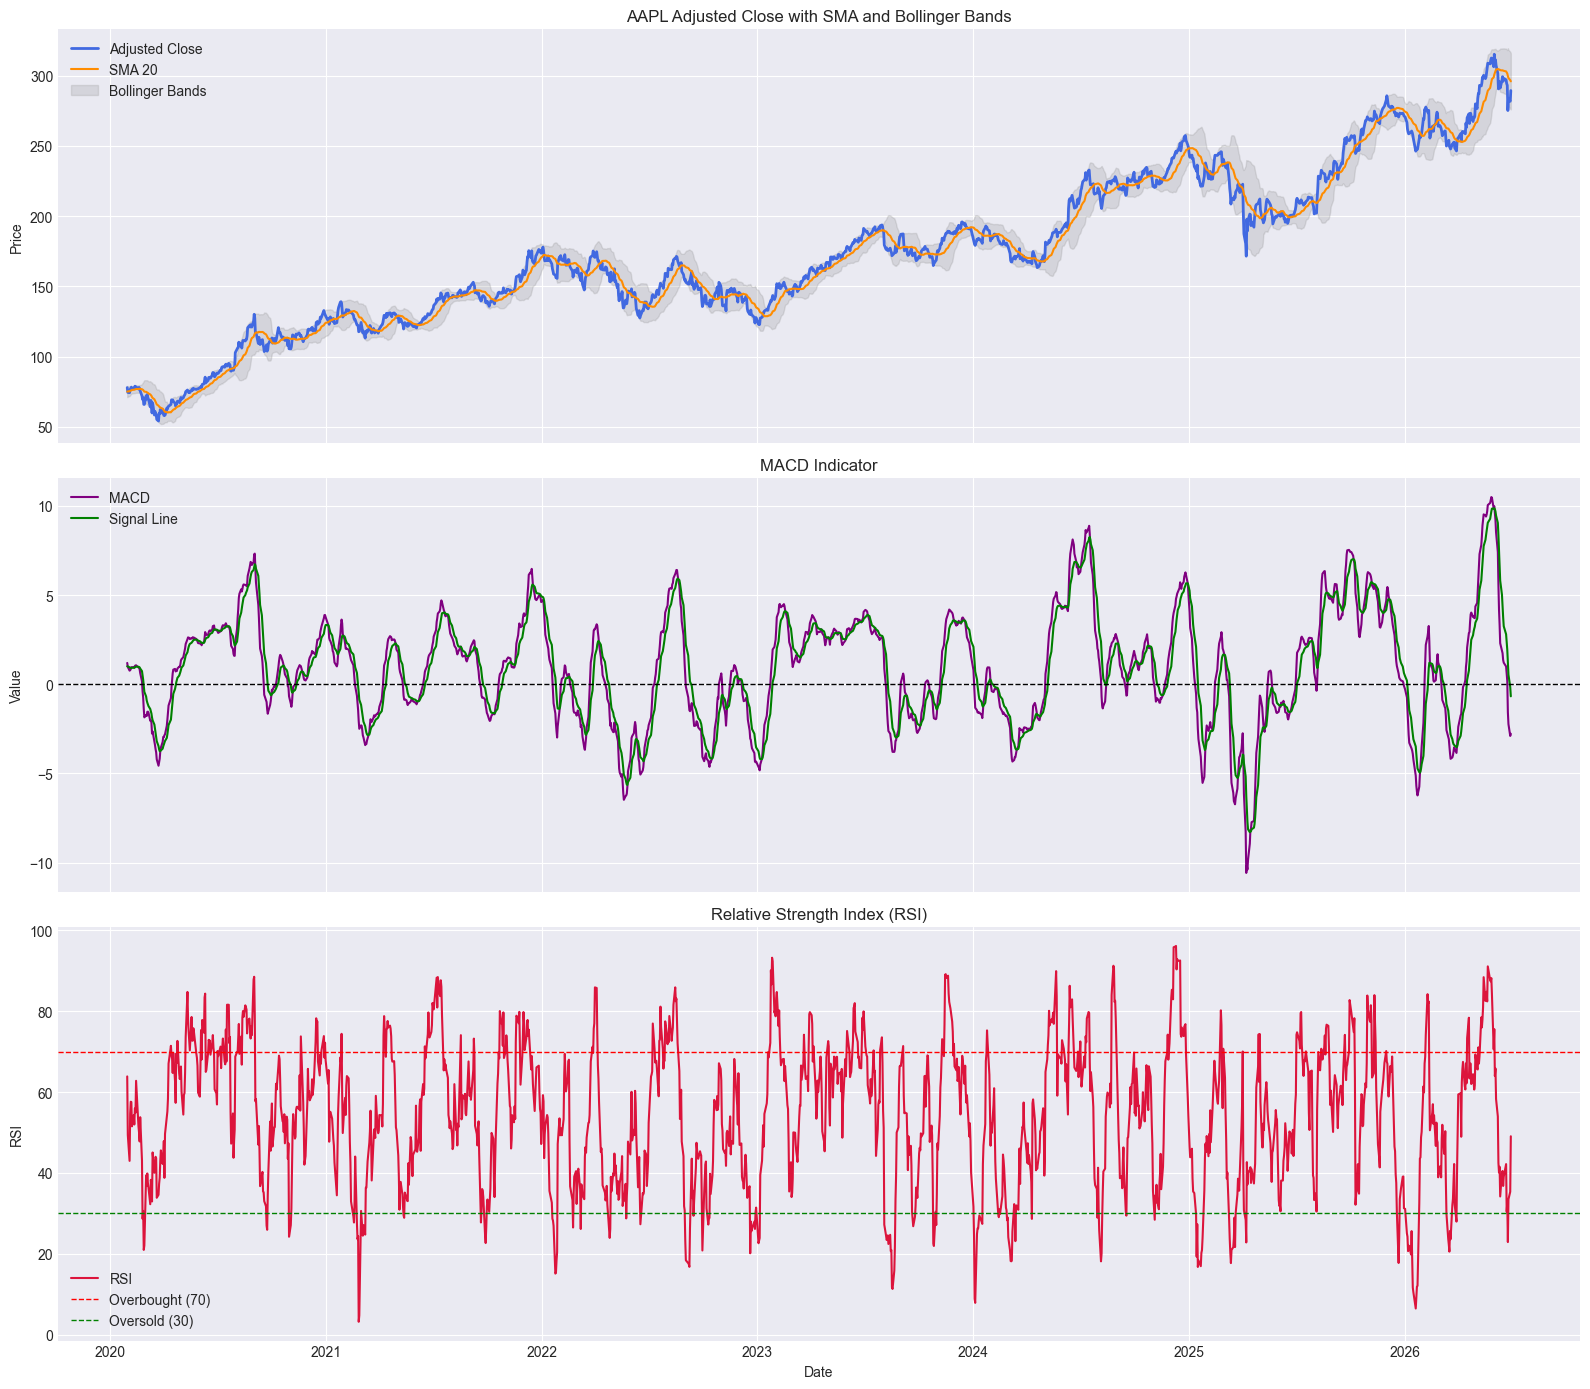

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

axes[0].plot(df[date_col], df['Adj_Close'], label='Adjusted Close', color='royalblue', linewidth=2)
axes[0].plot(df[date_col], df['SMA_20'], label='SMA 20', color='darkorange', linewidth=1.5)
axes[0].fill_between(df[date_col], df['BB_Lower'], df['BB_Upper'], color='gray', alpha=0.2, label='Bollinger Bands')
axes[0].set_title(f'{ticker} Adjusted Close with SMA and Bollinger Bands')
axes[0].set_ylabel('Price')
axes[0].legend()

axes[1].plot(df[date_col], df['MACD'], label='MACD', color='purple', linewidth=1.5)
axes[1].plot(df[date_col], df['MACD_Signal'], label='Signal Line', color='green', linewidth=1.5)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('MACD Indicator')
axes[1].set_ylabel('Value')
axes[1].legend()

axes[2].plot(df[date_col], df['RSI'], label='RSI', color='crimson', linewidth=1.5)
axes[2].axhline(70, color='red', linestyle='--', linewidth=1, label='Overbought (70)')
axes[2].axhline(30, color='green', linestyle='--', linewidth=1, label='Oversold (30)')
axes[2].set_title('Relative Strength Index (RSI)')
axes[2].set_ylabel('RSI')
axes[2].set_xlabel('Date')
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Preprocess the data for the LSTM model

Features are standardized with `StandardScaler` (fit on the training split only) and converted into sliding windows of 30 steps. The model's **target is the next-step Return** (percentage change in `Adj_Close`), not the raw price level.

This matters: a price-level target combined with a scaler fit on the training range forces the model to extrapolate outside that range the moment the stock trends beyond it -- exactly what produced the negative test R^2 in the original version. Returns stay in roughly the same scale regardless of the absolute price, so the model only has to learn stationary, repeatable dynamics.

A short data-sufficiency check also runs here: a 30-step window on too little history leaves very few training sequences relative to the model's parameter count, which is a second major cause of the earlier poor results (train RMSE 8.5 vs. test RMSE 15.5 -- a large overfitting gap). If you see the warning, re-run section 2 with an earlier `start_date`.

In [7]:
feature_columns = ['Adj_Close', 'MACD', 'RSI', 'SMA_20', 'BB_Upper', 'BB_Lower', 'Return']
target_column = 'Return'
target_index = feature_columns.index(target_column)
window_size = 30
forecast_horizon = 15

model_df = df[[date_col] + feature_columns].copy()

min_recommended_rows = window_size * 6
if len(model_df) < min_recommended_rows:
    print(
        f'Warning: only {len(model_df)} rows are available after indicator warm-up, '
        f'but at least {min_recommended_rows} are recommended for a {window_size}-step '
        'window. With too little history the LSTM sees very few training sequences '
        'relative to its parameter count and overfits badly (large train/test gap, '
        'negative test R^2). Re-run with an earlier start_date -- multi-year history '
        'is recommended for daily data.'
    )

split_index = int(len(model_df) * 0.8)
train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

feature_scaler = StandardScaler()
feature_scaler.fit(train_df[feature_columns])

scaled_features = feature_scaler.transform(model_df[feature_columns])
scaled_df = pd.DataFrame(scaled_features, columns=feature_columns)
scaled_df[date_col] = model_df[date_col].values


def create_sequences(data_array, window_size, target_index=0):
    X, y = [], []
    for i in range(window_size, len(data_array)):
        X.append(data_array[i-window_size:i])
        y.append(data_array[i, target_index])
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(scaled_df[feature_columns].values, window_size, target_index=target_index)
all_dates = model_df[date_col].iloc[window_size:].reset_index(drop=True)

# Previous actual close aligned with each target row, so a predicted return
# can be turned back into an absolute price: price[t-1] * (1 + return[t]).
prev_close_all = model_df['Adj_Close'].values[window_size - 1:-1]
actual_close_all = model_df['Adj_Close'].values[window_size:]

train_sequence_end = split_index - window_size
X_train, y_train = X_all[:train_sequence_end], y_all[:train_sequence_end]
X_test, y_test = X_all[train_sequence_end:], y_all[train_sequence_end:]
test_dates = all_dates.iloc[train_sequence_end:].reset_index(drop=True)

prev_close_train, prev_close_test = prev_close_all[:train_sequence_end], prev_close_all[train_sequence_end:]
actual_close_train, actual_close_test = actual_close_all[:train_sequence_end], actual_close_all[train_sequence_end:]

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

X_train shape: (1259, 30, 7)
X_test shape: (323, 30, 7)


## 7. Build and train the LSTM model

The model uses a single LSTM(32) layer (down from two stacked LSTM(64) layers) sized to match the modest amount of data typically available for this task -- the original two-layer, 64-unit model had far more parameters than the ~100-200 training sequences could support, which drives the train/test RMSE gap seen previously. Training also uses a smaller batch size (16) for more gradient updates per epoch, `ReduceLROnPlateau` to damp the noisy validation loss that comes from a small validation split, and a longer early-stopping patience so the schedule isn't cut off prematurely.

In [8]:
model = Sequential([
    LSTM(32, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=6,
    min_lr=1e-5
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.15,
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.0356 - val_loss: 0.7729 - learning_rate: 0.0010
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0064 - val_loss: 0.6443 - learning_rate: 0.0010
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0020 - val_loss: 0.5567 - learning_rate: 0.0010
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0007 - val_loss: 0.5735 - learning_rate: 0.0010
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9928 - val_loss: 0.5913 - learning_rate: 0.0010
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9795 - val_loss: 0.5811 - learning_rate: 0.0010
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9820 - val_loss: 0.5928 - learning_rate: 0.0010
Epoch 8/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9811 - val_loss: 0.6126 - learning_rate: 0.0010
Epoch 9/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9583 - val_loss: 0.5806 - learning_rate: 0.0010
Epoch 10/100
67/67 

## 8. Evaluate model performance

Because the model predicts returns, absolute prices are reconstructed as `previous_actual_close * (1 + predicted_return)` before computing metrics, so RMSE/MAE/R^2 are still reported in price terms and are directly comparable to the original version. Both Train and Test R^2 are now reported side by side to make any overfitting gap visible at a glance.

The R-squared formula used is:

\[
R^2 = 1 - 
rac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - ar{y})^2}
\]

In [9]:
def invert_target_scale(scaled_target_values, scaler, feature_columns, target_col=target_column):
    temp = np.zeros((len(scaled_target_values), len(feature_columns)))
    target_idx = feature_columns.index(target_col)
    temp[:, target_idx] = scaled_target_values.reshape(-1)
    inverted = scaler.inverse_transform(temp)
    return inverted[:, target_idx]

train_pred_scaled = model.predict(X_train, verbose=0)
test_pred_scaled = model.predict(X_test, verbose=0)

train_pred_return = invert_target_scale(train_pred_scaled, feature_scaler, feature_columns)
test_pred_return = invert_target_scale(test_pred_scaled, feature_scaler, feature_columns)

# Reconstruct absolute prices from the previous actual close plus the
# predicted return, instead of predicting price level directly.
train_actual = actual_close_train
train_pred = prev_close_train * (1 + train_pred_return)

test_actual = actual_close_test
test_pred = prev_close_test * (1 + test_pred_return)

train_rmse = math.sqrt(mean_squared_error(train_actual, train_pred))
test_rmse = math.sqrt(mean_squared_error(test_actual, test_pred))
train_mae = mean_absolute_error(train_actual, train_pred)
test_mae = mean_absolute_error(test_actual, test_pred)
train_r2 = r2_score(train_actual, train_pred)
test_r2 = r2_score(test_actual, test_pred)

metrics_df = pd.DataFrame({
    'Metric': ['Train RMSE', 'Test RMSE', 'Train MAE', 'Test MAE', 'Train R^2', 'Test R^2'],
    'Value': [train_rmse, test_rmse, train_mae, test_mae, train_r2, test_r2]
})
metrics_df

,Metric,Value
0,Train RMSE,2.742185
1,Test RMSE,4.501364
2,Train MAE,2.032443
3,Test MAE,3.124517
4,Train R^2,0.995684
5,Test R^2,0.981353


## 9. Visualize actual vs predicted values

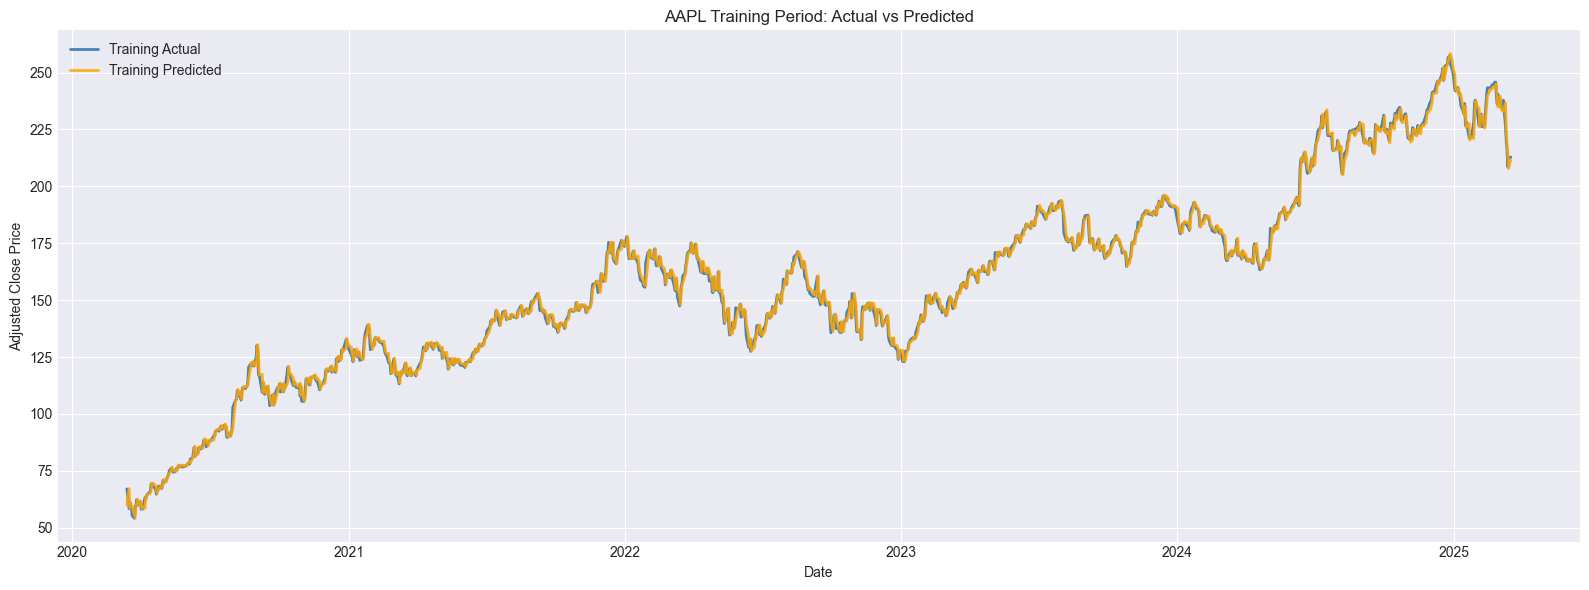

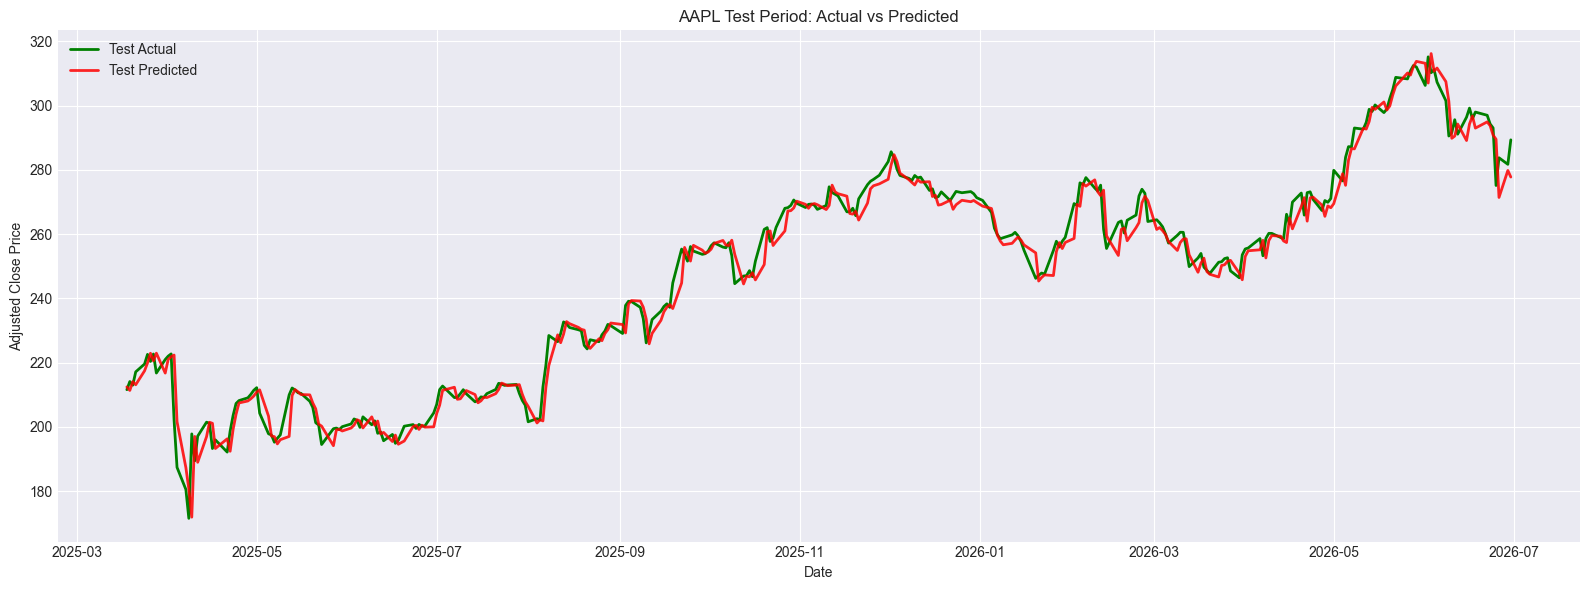

In [10]:
train_dates = all_dates.iloc[:train_sequence_end].reset_index(drop=True)

plt.figure(figsize=(16, 6))
plt.plot(train_dates, train_actual, label='Training Actual', color='steelblue', linewidth=2)
plt.plot(train_dates, train_pred, label='Training Predicted', color='orange', linewidth=2, alpha=0.85)
plt.title(f'{ticker} Training Period: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 6))
plt.plot(test_dates, test_actual, label='Test Actual', color='green', linewidth=2)
plt.plot(test_dates, test_pred, label='Test Predicted', color='red', linewidth=2, alpha=0.85)
plt.title(f'{ticker} Test Period: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Forecast the next 15 periods

The model still forecasts recursively, feeding each step's prediction back into the window -- but now it predicts the next Return and compounds it onto the last known price (`price[t] = price[t-1] * (1 + return[t])`) rather than predicting price level directly. The technical-indicator columns are carried forward unchanged at each step since recomputing them would require a buffer of true future prices; treat this multi-step forecast as directional rather than precise.

In [11]:
adj_idx = feature_columns.index('Adj_Close')
ret_idx = feature_columns.index('Return')

current_sequence = scaled_df[feature_columns].values[-window_size:].copy()
last_actual_price = model_df['Adj_Close'].iloc[-1]
future_prices = []

for _ in range(forecast_horizon):
    next_return_scaled = model.predict(current_sequence.reshape(1, window_size, len(feature_columns)), verbose=0)[0, 0]
    next_return = invert_target_scale(np.array([next_return_scaled]), feature_scaler, feature_columns)[0]

    next_price = last_actual_price * (1 + next_return)
    future_prices.append(next_price)

    # Roll the window forward: Adj_Close and Return take the new prediction,
    # the technical indicators are carried forward unchanged since recomputing
    # MACD/RSI/SMA/Bollinger Bands would require a buffer of true future
    # prices we don't have. This is a known simplification, so treat
    # multi-step forecasts as directional rather than precise.
    next_row_scaled = current_sequence[-1].copy()
    next_row_scaled[adj_idx] = (next_price - feature_scaler.mean_[adj_idx]) / feature_scaler.scale_[adj_idx]
    next_row_scaled[ret_idx] = next_return_scaled
    current_sequence = np.vstack([current_sequence[1:], next_row_scaled])

    last_actual_price = next_price

future_predictions = np.array(future_prices)

last_timestamp = model_df[date_col].iloc[-1]
if interval in {'1d', '5d'}:
    future_dates = pd.bdate_range(start=last_timestamp + pd.Timedelta(days=1), periods=forecast_horizon)
elif interval == '1wk':
    future_dates = pd.date_range(start=last_timestamp + pd.Timedelta(weeks=1), periods=forecast_horizon, freq='W')
elif interval in {'1mo', '3mo'}:
    freq = 'MS' if interval == '1mo' else 'QS'
    future_dates = pd.date_range(start=last_timestamp + pd.offsets.DateOffset(months=1), periods=forecast_horizon, freq=freq)
elif interval in {'1h', '60m'}:
    future_dates = pd.date_range(start=last_timestamp + pd.Timedelta(hours=1), periods=forecast_horizon, freq='H')
elif interval == '90m':
    future_dates = pd.date_range(start=last_timestamp + pd.Timedelta(minutes=90), periods=forecast_horizon, freq='90min')
else:
    minute_map = {'1m': '1min', '2m': '2min', '5m': '5min', '15m': '15min', '30m': '30min'}
    freq = minute_map.get(interval, 'D')
    start_dt = last_timestamp + pd.to_timedelta(freq)
    future_dates = pd.date_range(start=start_dt, periods=forecast_horizon, freq=freq)

forecast_df = pd.DataFrame({
    'Forecast_Date': future_dates,
    'Forecasted_Adj_Close': future_predictions
})
forecast_df

,Forecast_Date,Forecasted_Adj_Close
0,2026-07-01,285.414509
1,2026-07-02,281.543486
2,2026-07-03,277.800058
3,2026-07-06,274.207782
4,2026-07-07,270.752713
5,2026-07-08,267.416101
6,2026-07-09,264.190104
7,2026-07-10,261.065436
8,2026-07-13,258.037599
9,2026-07-14,255.107591


## 11. Visualize the 15-step forecast

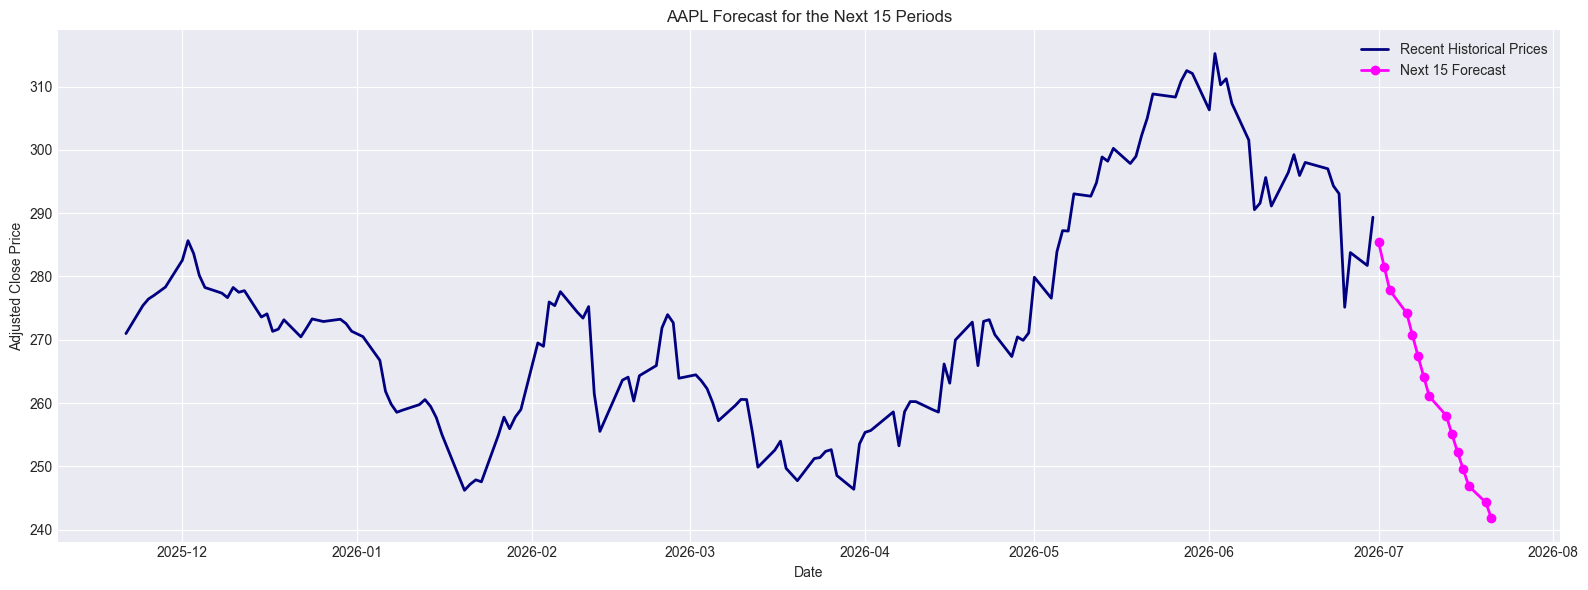

In [12]:
plt.figure(figsize=(16, 6))
plt.plot(model_df[date_col].tail(150), model_df['Adj_Close'].tail(150), label='Recent Historical Prices', color='navy', linewidth=2)
plt.plot(forecast_df['Forecast_Date'], forecast_df['Forecasted_Adj_Close'], label='Next 15 Forecast', color='magenta', linewidth=2, marker='o')
plt.title(f'{ticker} Forecast for the Next {forecast_horizon} Periods')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.tight_layout()
plt.show()

## 12. Save outputs

This cell exports processed data, metrics, and forecast results so they can be added to the GitHub repository alongside the notebook.

In [13]:
output_prefix = f"{ticker}_{interval}_{start_date}_to_{end_date}".replace(':', '-')

processed_path = f"{output_prefix}_processed_data.csv"
metrics_path = f"{output_prefix}_metrics.csv"
forecast_path = f"{output_prefix}_forecast.csv"

model_df.to_csv(processed_path, index=False)
metrics_df.to_csv(metrics_path, index=False)
forecast_df.to_csv(forecast_path, index=False)

print('Saved files:')
print('-', processed_path)
print('-', metrics_path)
print('-', forecast_path)

Saved files:
- AAPL_1d_2020-01-01_to_2026-07-01_processed_data.csv
- AAPL_1d_2020-01-01_to_2026-07-01_metrics.csv
- AAPL_1d_2020-01-01_to_2026-07-01_forecast.csv
